# 02 — Preprocessing & Feature Engineering

# Predicting Gallstone Disease from Clinical + Bioimpedance

**Domain:** Healthcare | **Task:** Binary Classification | **Data:** Tabular  
**Dataset:** `data/dataset-uci.csv`  
**Target column:** `Gallstone Status` (Yes[1]/No[0])

Run the cells top-to-bottom. These notebooks avoid seaborn per instructions and use pure matplotlib for charts.

## Objectives
- Clean column names (optional)
- Encode target to 0/1
- Optional outlier clipping (robust scaling later handles much of this)
- Train/test split and scaling
- Persist processed arrays for reuse

In [37]:
# Core setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Settings
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)

DATA_PATH = "../data/raw/dataset-uci.csv"
RANDOM_STATE = 42

# Load
df = pd.read_csv(DATA_PATH)
print(df.shape)
df.head()

(319, 39)


,Gallstone Status,Age,Gender,Comorbidity,Coronary Artery Disease (CAD),Hypothyroidism,Hyperlipidemia,Diabetes Mellitus (DM),Height,Weight,Body Mass Index (BMI),Total Body Water (TBW),Extracellular Water (ECW),Intracellular Water (ICW),Extracellular Fluid/Total Body Water (ECF/TBW),Total Body Fat Ratio (TBFR) (%),Lean Mass (LM) (%),Body Protein Content (Protein) (%),Visceral Fat Rating (VFR),Bone Mass (BM),Muscle Mass (MM),Obesity (%),Total Fat Content (TFC),Visceral Fat Area (VFA),Visceral Muscle Area (VMA) (Kg),Hepatic Fat Accumulation (HFA),Glucose,Total Cholesterol (TC),Low Density Lipoprotein (LDL),High Density Lipoprotein (HDL),Triglyceride,Aspartat Aminotransferaz (AST),Alanin Aminotransferaz (ALT),Alkaline Phosphatase (ALP),Creatinine,Glomerular Filtration Rate (GFR),C-Reactive Protein (CRP),Hemoglobin (HGB),Vitamin D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


## Clean column names (optional, reproducible)

In [38]:
def clean_cols(cols):
    return [c.strip().replace(' ', '_').replace('(', '').replace(')', '').replace('%','pct').replace('/','_') for c in cols]

df.columns = clean_cols(df.columns)
assert "Gallstone_Status" in df.columns, "After cleaning, expected 'Gallstone_Status'."
df.head()

,Gallstone_Status,Age,Gender,Comorbidity,Coronary_Artery_Disease_CAD,Hypothyroidism,Hyperlipidemia,Diabetes_Mellitus_DM,Height,Weight,Body_Mass_Index_BMI,Total_Body_Water_TBW,Extracellular_Water_ECW,Intracellular_Water_ICW,Extracellular_Fluid_Total_Body_Water_ECF_TBW,Total_Body_Fat_Ratio_TBFR_pct,Lean_Mass_LM_pct,Body_Protein_Content_Protein_pct,Visceral_Fat_Rating_VFR,Bone_Mass_BM,Muscle_Mass_MM,Obesity_pct,Total_Fat_Content_TFC,Visceral_Fat_Area_VFA,Visceral_Muscle_Area_VMA_Kg,Hepatic_Fat_Accumulation_HFA,Glucose,Total_Cholesterol_TC,Low_Density_Lipoprotein_LDL,High_Density_Lipoprotein_HDL,Triglyceride,Aspartat_Aminotransferaz_AST,Alanin_Aminotransferaz_ALT,Alkaline_Phosphatase_ALP,Creatinine,Glomerular_Filtration_Rate_GFR,C-Reactive_Protein_CRP,Hemoglobin_HGB,Vitamin_D
0,0,50,0,0,0,0,0,0,185,92.8,27.1,52.9,21.2,31.7,40.0,19.2,80.84,18.88,9,3.7,71.4,23.4,17.8,10.6,39.7,0,102.0,250.0,175.0,40.0,134.0,20.0,22.0,87.0,0.82,112.47,0.0,16.0,33.0
1,0,47,0,1,0,0,0,0,176,94.5,30.5,43.1,19.5,23.6,45.0,32.8,67.20,16.68,15,3.2,60.3,38.8,31.0,18.4,32.7,0,94.0,172.0,108.0,43.0,103.0,14.0,13.0,46.0,0.87,107.10,0.0,14.4,25.0
2,0,61,0,0,0,0,0,0,171,91.1,31.2,47.2,20.1,27.1,43.0,27.3,72.67,16.35,15,3.3,62.9,41.7,24.9,16.2,34.0,0,103.0,179.0,124.0,43.0,69.0,18.0,14.0,66.0,1.25,65.51,0.0,16.2,30.2
3,0,41,0,0,0,0,0,0,168,67.7,24.0,41.4,17.0,24.4,41.0,15.8,84.19,16.90,6,2.9,54.1,9.0,10.7,6.5,29.2,1,69.0,173.0,73.0,59.0,53.0,20.0,12.0,34.0,1.02,94.10,0.0,15.4,35.4
4,0,42,0,0,0,0,0,0,178,89.6,28.3,51.4,20.0,31.4,39.0,20.0,80.02,16.81,8,3.5,68.2,28.6,17.9,10.4,37.4,2,109.0,205.0,154.0,30.0,326.0,27.0,54.0,71.0,0.82,112.47,0.0,16.8,40.6


## Encode target and split features/labels

In [39]:
y = df["Gallstone_Status"].astype(int)
X = df.drop(columns=["Gallstone_Status"])
feature_names = X.columns.tolist()

print("X shape:", X.shape, "| y shape:", y.shape)
print("Target distribution:", y.value_counts().to_dict())

X shape: (319, 38) | y shape: (319,)
Target distribution: {0: 161, 1: 158}


## Outlier Detection & Analysis

In [40]:
from scipy import stats

def detect_outliers_iqr(df, columns=None, multiplier=1.5):
    """
    Detect outliers using IQR method
    multiplier: 1.5 = standard, 3.0 = conservative
    """
    if columns is None:
        columns = df.select_dtypes(include=[np.number]).columns
    
    outlier_info = {}
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - multiplier * IQR
        upper_bound = Q3 + multiplier * IQR
        
        outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)].index
        outlier_info[col] = {
            'count': len(outliers),
            'percentage': len(outliers) / len(df) * 100,
            'lower_bound': lower_bound,
            'upper_bound': upper_bound,
            'indices': outliers.tolist(),
            'min_outlier': df.loc[outliers, col].min() if len(outliers) > 0 else None,
            'max_outlier': df.loc[outliers, col].max() if len(outliers) > 0 else None
        }
    
    return outlier_info

# Analyze outliers in the full dataset before splitting
outlier_results = detect_outliers_iqr(X)

print("Outlier Analysis (IQR method - 1.5x multiplier):")
print("=" * 60)
print(f"{'Feature':<25} {'Outliers':<8} {'%':<6} {'Range':<20}")
print("-" * 60)

total_outliers = 0
features_with_outliers = []

for feature, info in outlier_results.items():
    if info['count'] > 0:
        features_with_outliers.append(feature)
        total_outliers += info['count']
        range_str = f"[{info['min_outlier']:.1f}, {info['max_outlier']:.1f}]"
        print(f"{feature:<25} {info['count']:<8} {info['percentage']:<6.1f} {range_str:<20}")

print(f"\nSummary:")
print(f"- Features with outliers: {len(features_with_outliers)}/{len(X.columns)}")
print(f"- Total outlier observations: {total_outliers}")

# Convert set to list for pandas indexing
all_outlier_indices = []
for info in outlier_results.values():
    all_outlier_indices.extend(info['indices'])
unique_outlier_indices = list(set(all_outlier_indices))

print(f"- Samples affected: {len(unique_outlier_indices)}/{len(X)} ({len(unique_outlier_indices)/len(X)*100:.1f}%)")

# Check overlap with gallstone status
if total_outliers > 0:
    outlier_gallstone_rate = y.loc[unique_outlier_indices].mean()
    overall_gallstone_rate = y.mean()
    print(f"- Gallstone rate in outliers: {outlier_gallstone_rate:.3f} vs overall: {overall_gallstone_rate:.3f}")

Outlier Analysis (IQR method - 1.5x multiplier):
Feature                   Outliers %      Range               
------------------------------------------------------------
Age                       2        0.6    [87.0, 96.0]        
Comorbidity               2        0.6    [3.0, 3.0]          
Coronary_Artery_Disease_CAD 12       3.8    [1.0, 1.0]          
Hypothyroidism            9        2.8    [1.0, 1.0]          
Hyperlipidemia            8        2.5    [1.0, 1.0]          
Diabetes_Mellitus_DM      43       13.5   [1.0, 1.0]          
Weight                    2        0.6    [125.8, 143.5]      
Body_Mass_Index_BMI       5        1.6    [44.3, 49.7]        
Total_Body_Water_TBW      2        0.6    [13.0, 66.2]        
Extracellular_Water_ECW   1        0.3    [27.8, 27.8]        
Intracellular_Water_ICW   1        0.3    [57.1, 57.1]        
Extracellular_Fluid_Total_Body_Water_ECF_TBW 7        2.2    [29.2, 52.0]        
Body_Protein_Content_Protein_pct 8        2.5    [

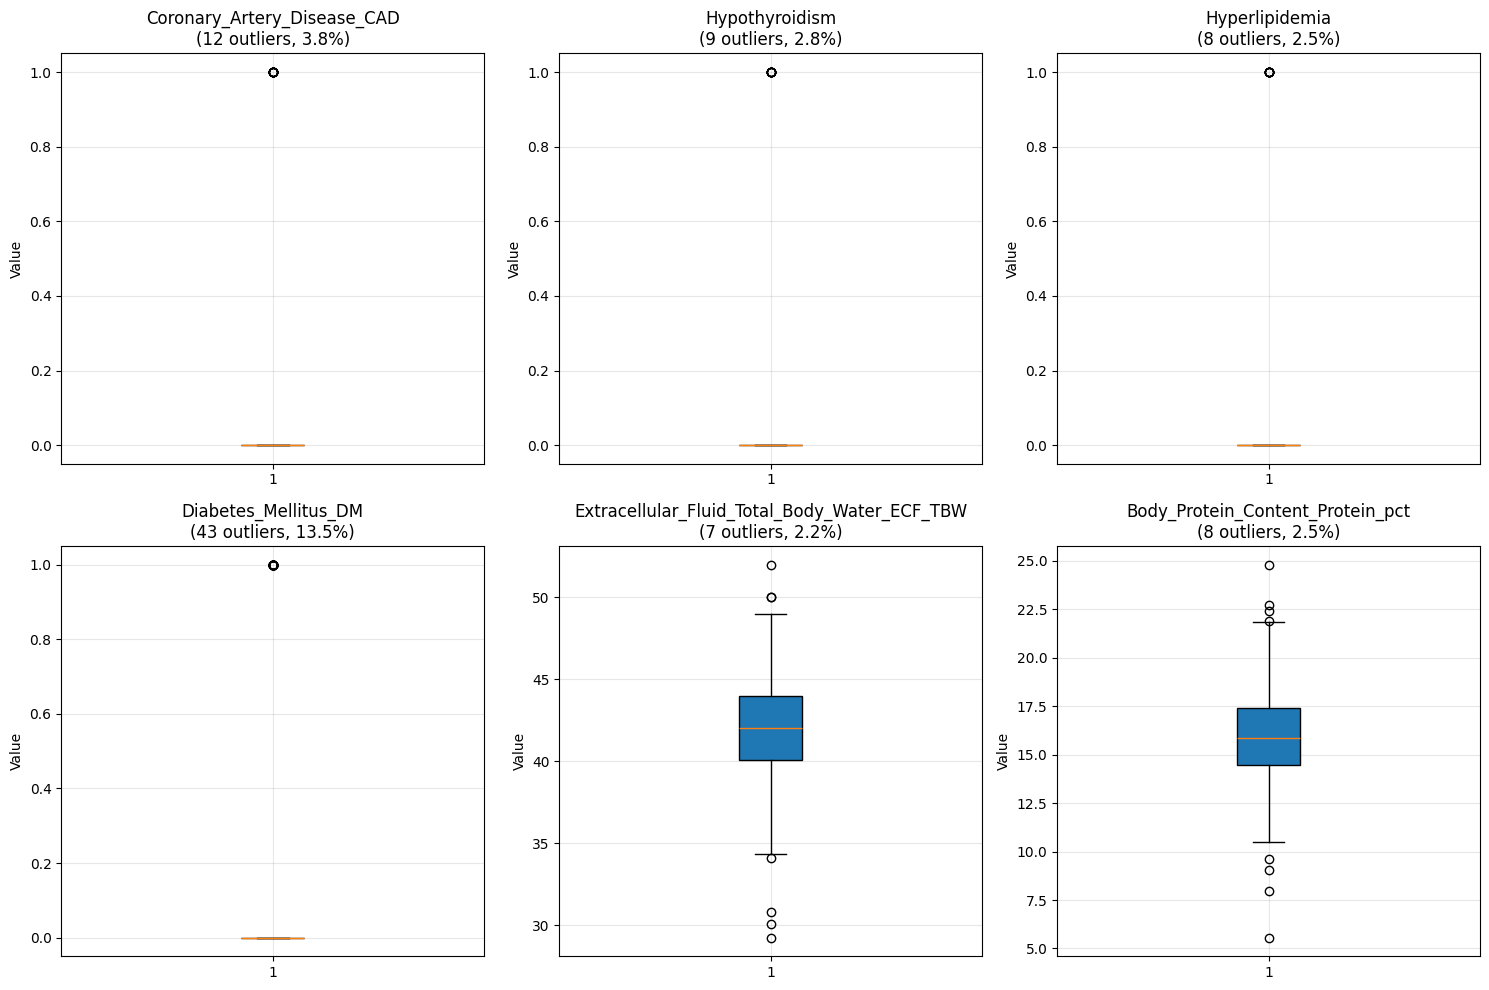

In [41]:
# Visualize top outlier features for medical assessment
high_outlier_features = [k for k, v in outlier_results.items() if v['count'] > 5]

if len(high_outlier_features) > 0:
    # Create subplots for features with most outliers
    n_plots = min(6, len(high_outlier_features))
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    axes = axes.ravel()
    
    for i, feature in enumerate(high_outlier_features[:n_plots]):
        # Box plot
        axes[i].boxplot(X[feature], patch_artist=True)
        axes[i].set_title(f'{feature}\n({outlier_results[feature]["count"]} outliers, {outlier_results[feature]["percentage"]:.1f}%)')
        axes[i].set_ylabel('Value')
        axes[i].grid(True, alpha=0.3)
    
    # Remove empty subplots
    for j in range(n_plots, len(axes)):
        fig.delaxes(axes[j])
    
    plt.tight_layout()
    plt.show()
else:
    print("No features with >5 outliers to visualize")

In [42]:
# Medical plausibility check for key biomarkers
medical_ranges = {
    'Age': (18, 100),
    'Body Mass Index (BMI)': (15, 50),  # Extreme but possible
    'Glucose': (50, 400),  # mg/dL - covers hypoglycemia to severe diabetes
    'Total Cholesterol (TC)': (100, 400),  # mg/dL
    'Low Density Lipoprotein (LDL)': (50, 300),  # mg/dL
    'High Density Lipoprotein (HDL)': (20, 100),  # mg/dL
    'Triglyceride': (30, 1000),  # mg/dL
    'Hemoglobin (HGB)': (8, 20),  # g/dL
    'Creatinine': (0.5, 5.0),  # mg/dL
}

print("\nMedical Plausibility Assessment:")
print("=" * 50)
suspicious_outliers = []

for feature, (min_normal, max_normal) in medical_ranges.items():
    if feature in X.columns and feature in outlier_results:
        info = outlier_results[feature]
        if info['count'] > 0:
            min_val = info['min_outlier']
            max_val = info['max_outlier']
            
            # Check if outliers are outside medical plausibility
            medically_implausible = (min_val < min_normal) or (max_val > max_normal)
            
            status = "⚠️  SUSPICIOUS" if medically_implausible else "✅ Plausible"
            print(f"{feature:<25} {min_val:>8.1f} - {max_val:<8.1f} {status}")
            
            if medically_implausible:
                suspicious_outliers.append(feature)

if suspicious_outliers:
    print(f"\n⚠️  Features with potentially implausible outliers: {suspicious_outliers}")
    print("→ Consider manual review or conservative outlier removal for these features")
else:
    print("\n✅ All outliers appear medically plausible")


Medical Plausibility Assessment:
Age                           87.0 - 96.0     ✅ Plausible
Glucose                      138.0 - 575.0    ⚠️  SUSPICIOUS
Triglyceride                 307.0 - 838.0    ✅ Plausible
Creatinine                     1.3 - 1.5      ✅ Plausible

⚠️  Features with potentially implausible outliers: ['Glucose']
→ Consider manual review or conservative outlier removal for these features


### Outlier Decision Framework

Based on the analysis above, decide on outlier handling:

**Option 1: Keep all data (Recommended for medical data)**
- Pros: Preserves all medical information, no data loss
- Cons: Potential model sensitivity to extreme values
- Best for: When outliers appear medically plausible

**Option 2: Conservative outlier removal (3x IQR)**
- Pros: Removes only extreme outliers, preserves most data
- Cons: Still loses some potentially valuable medical cases
- Best for: When some outliers are clearly implausible

**Option 3: Use RobustScaler instead of StandardScaler**
- Pros: Handles outliers through robust scaling, no data loss
- Cons: May not completely solve outlier issues
- Best for: When you want outlier-resistant preprocessing

In [43]:
# Decision: Choose your outlier handling approach

# OPTION 1: Keep all data (default - recommended for medical data)
X_clean = X.copy()
y_clean = y.copy()
message = "Keeping all data due to medical context."

# OPTION 2: Conservative outlier removal (uncomment if needed)
# conservative_outliers = detect_outliers_iqr(X, multiplier=3.0)
# outlier_indices = set([idx for info in conservative_outliers.values() for idx in info['indices']])
# clean_indices = X.index.difference(outlier_indices)
# X_clean = X.loc[clean_indices]
# y_clean = y.loc[clean_indices]
# print(f"Removed {len(outlier_indices)} extreme outliers, keeping {len(X_clean)} samples")
# message = "Removed extreme outliers using conservative IQR method."

print(f"Final dataset shape: {X_clean.shape}")
print(f"✅ Outlier analysis complete. {message}")

Final dataset shape: (319, 38)
✅ Outlier analysis complete. Keeping all data due to medical context.


## Train/validation/test split

In [44]:
from sklearn.model_selection import train_test_split

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=RANDOM_STATE, stratify=y
)
X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=RANDOM_STATE, stratify=y_temp
)

print("Train:", X_train.shape, "Valid:", X_valid.shape, "Test:", X_test.shape)

Train: (223, 38) Valid: (48, 38) Test: (48, 38)


## Scaling (StandardScaler) — save fitted scaler

In [45]:
from sklearn.preprocessing import StandardScaler, RobustScaler
import joblib

# OPTION 1: Standard Scaler (default)
scaler = StandardScaler()
scaler_name = "StandardScaler"

# OPTION 2: Robust Scaler (uncomment to use - better for outliers)
# scaler = RobustScaler()
# scaler_name = "RobustScaler"

# Apply scaling
X_train_scaled = scaler.fit_transform(X_train)
X_valid_scaled = scaler.transform(X_valid)
X_test_scaled  = scaler.transform(X_test)

# Save scaler in models
joblib.dump(scaler, "../data/models/scaler.joblib")

# Save processed arrays in processed folder
np.save("../data/processed/X_train_scaled.npy", X_train_scaled)
np.save("../data/processed/X_valid_scaled.npy", X_valid_scaled)
np.save("../data/processed/X_test_scaled.npy",  X_test_scaled)
np.save("../data/processed/y_train.npy", y_train.values)
np.save("../data/processed/y_valid.npy", y_valid.values)
np.save("../data/processed/y_test.npy",  y_test.values)

# Save feature names in processed folder
pd.Series(feature_names).to_csv("../data/processed/feature_names.csv", index=False)

print(f"✓ Saved scaled arrays using {scaler_name}.")
print(f"  - Scaler: data/models/scaler.joblib")
print(f"  - Processed data: data/processed/")

# Display scaling info
print(f"\nScaling method: {scaler_name}")
if isinstance(scaler, StandardScaler):
    print("  → Uses mean and standard deviation")
    print("  → Best for normally distributed data")
elif isinstance(scaler, RobustScaler):
    print("  → Uses median and IQR (outlier-resistant)")
    print("  → Better for data with outliers")

✓ Saved scaled arrays using StandardScaler.
  - Scaler: data/models/scaler.joblib
  - Processed data: data/processed/

Scaling method: StandardScaler
  → Uses mean and standard deviation
  → Best for normally distributed data


## (Optional) Simple feature creation examples

In [46]:
# Example: BMI is likely already present; if not, show pattern
# if set(['Weight','Height']).issubset(set(X.columns)):
#     X['BMI_calc'] = X['Weight'] / (X['Height']/100)**2

"Add domain features here if needed."

'Add domain features here if needed.'